Tamanho da imagem :  (3692, 2812)
[[245 245 245 ... 245 245 245]
 [245 245 245 ... 245 245 245]
 [245 245 245 ... 245 245 245]
 ...
 [245 245 245 ... 246 246 246]
 [245 245 245 ... 246 246 246]
 [245 245 245 ... 246 246 246]]


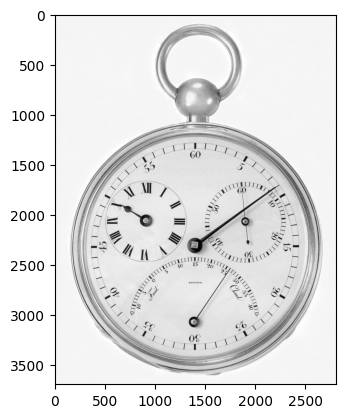

In [9]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import math


img = cv2.imread("relogio.tif", cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap='gray', vmin=0, vmax=255);

print('Tamanho da imagem : ',img.shape)
# convertendo para 300dpi

print(img)




linhas = img.shape[0]
colunas = img.shape[1];



In [12]:

contadorLinhas = 0
contaorColunas = 0

imgRedimensionada300 = np.zeros((int(linhas/4.16), int(colunas/4.16)), dtype=np.uint8)
i = 0
while contadorLinhas < imgRedimensionada300.shape[0] and i < linhas:
    j = 0
    contaorColunas = 0
    while contaorColunas < imgRedimensionada300.shape[1] and j < colunas:
        imgRedimensionada300[contadorLinhas, contaorColunas] = img[math.floor(i), math.floor(j)]
        contaorColunas += 1
        j += 4.16
    contadorLinhas += 1
    i += 4.16
        
    





        


Tamanho da imagem redimensionada :  (887, 675)


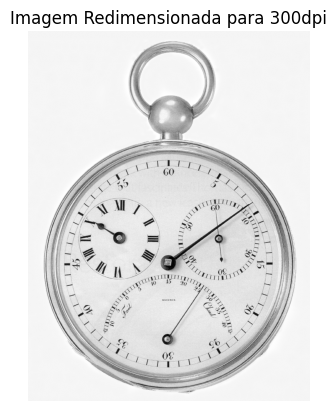

In [13]:
plt.imshow(imgRedimensionada300, cmap='gray', vmin=0, vmax=255);
print('Tamanho da imagem redimensionada : ',imgRedimensionada300.shape)
plt.title('Imagem Redimensionada para 300dpi')
plt.axis('off')
plt.show()


Tamanho da imagem redimensionada :  (443, 337)


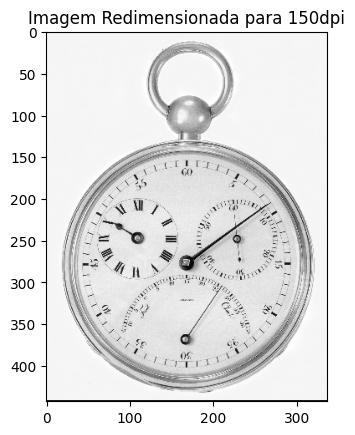

In [15]:


fator = 1250/150
largura = img.shape[1]
altura = img.shape[0]

nova_largura = int(largura/fator)
nova_altura = int(altura/fator)

imgRedimensionada150 = np.zeros((nova_altura,nova_largura), dtype=np.uint8)



cont_largura = []
cont_altura = []
soma_largura = 0
soma_altura = 0

while soma_largura <= largura:

    cont_largura.append(soma_largura)
    soma_largura += fator

while soma_altura <= altura:
    cont_altura.append(soma_altura)
    soma_altura += fator

for i in range(0, nova_altura-1):
    for j in range(0, nova_largura-1):
        imgRedimensionada150[i,j] = img[int(cont_altura[i]),int(cont_largura[j])]


plt.imshow(imgRedimensionada150, cmap='gray', vmin=0, vmax=255);
print('Tamanho da imagem redimensionada : ',imgRedimensionada150.shape)
plt.title('Imagem Redimensionada para 150dpi')
plt.show()

Tamanho da imagem redimensionada :  (212, 161)


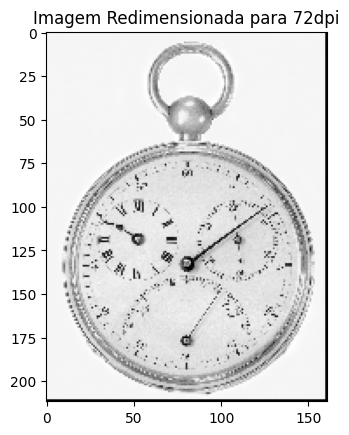

In [6]:
fator = 1250/72
largura = img.shape[1]
altura = img.shape[0]

nova_largura = int(largura/fator)
nova_altura = int(altura/fator)

imgRedimensionada72 = np.zeros((nova_altura,nova_largura), dtype=np.uint8)



cont_largura = []
cont_altura = []
soma_largura = 0
soma_altura = 0

while (soma_largura <= largura):

    cont_largura.append(soma_largura)
    soma_largura += fator

while (soma_altura <= altura):
    cont_altura.append(soma_altura)
    soma_altura += fator

for i in range(0, nova_altura-1):
    for j in range(0, nova_largura-1):
        imgRedimensionada72[i,j] = img[int(cont_altura[i]),int(cont_largura[j])]


plt.imshow(imgRedimensionada72, cmap='gray', vmin=0, vmax=255);
print('Tamanho da imagem redimensionada : ',imgRedimensionada72.shape)
plt.title('Imagem Redimensionada para 72dpi')
plt.show()

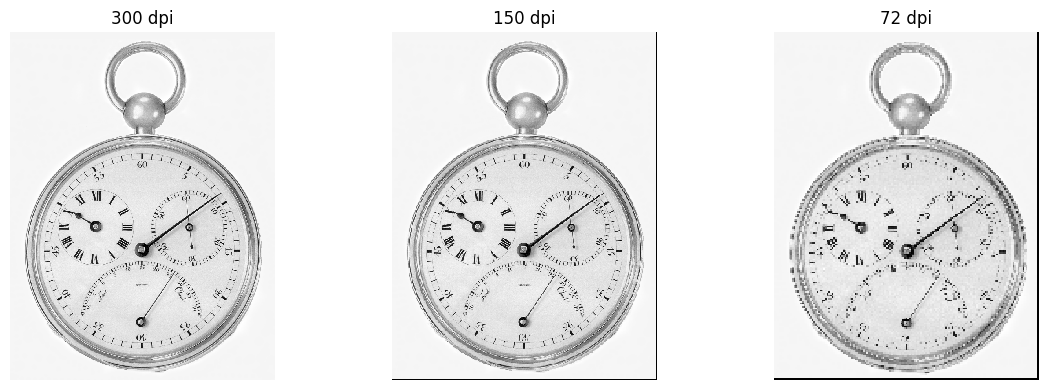

In [7]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(imgRedimensionada300, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title('300 dpi')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(imgRedimensionada150, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title('150 dpi')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(imgRedimensionada72, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title('72 dpi')
plt.axis('off')

plt.tight_layout()
plt.show()

In [21]:
def recalcular_imagem(imagem, dpi_atual, dpi_desejado):
    fator = dpi_atual / dpi_desejado  
    largura = imagem.shape[1]
    altura = imagem.shape[0]
    nova_largura = int(largura / fator)
    nova_altura = int(altura / fator)
    img_redimensionada = np.zeros((nova_altura, nova_largura), dtype=np.uint8)

    cont_largura = []
    cont_altura = []
    soma_largura = 0.0
    soma_altura = 0.0

    for i in range(0, nova_altura-1, fator):
        for j in range(0, nova_largura-1, fator):
            img_redimensionada[i,j] = img[math.floor(i),math.floor(j)]

    return img_redimensionada

In [23]:



img_test_72 = recalcular_imagem(img, 1250, 300)

plt.imshow(img_test_72, cmap='gray', vmin=0, vmax=255)
plt.title('recalcular_imagem resultado')
plt.axis('off')


print('Tamanho da imagem redimensionada : ',img_test_72.shape)
plt.tight_layout()
plt.show()

TypeError: 'float' object cannot be interpreted as an integer

Tamanho da imagem :  (452, 374)


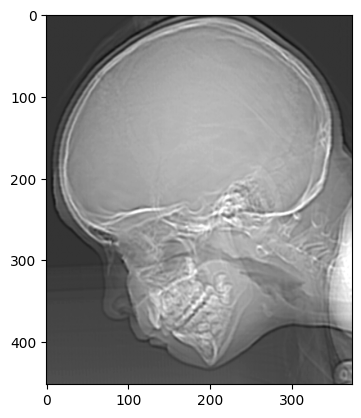

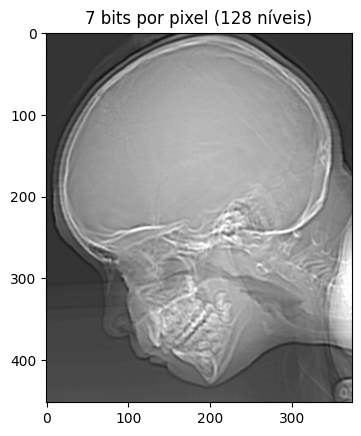

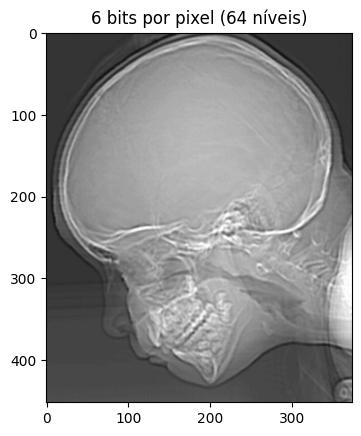

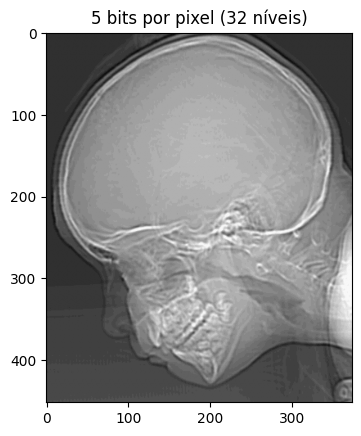

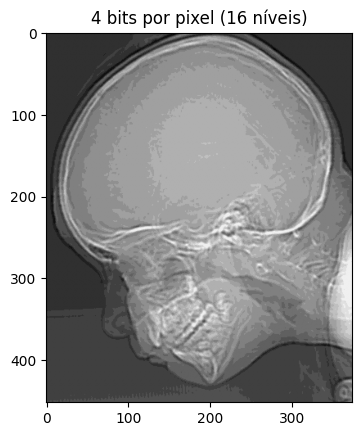

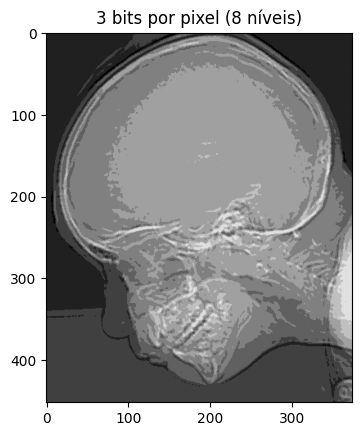

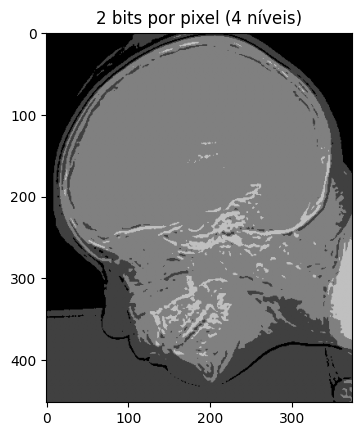

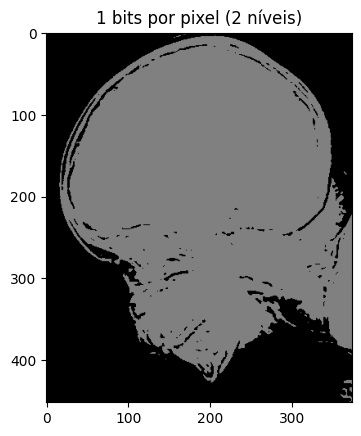

In [3]:
import cv2
import matplotlib.pyplot as plt


imgScull = cv2.imread("ctskull-256.tif", cv2.IMREAD_GRAYSCALE)
plt.imshow(imgScull, cmap='gray', vmin=0, vmax=255);

print('Tamanho da imagem : ',imgScull.shape);

def quantizacao(img,bits):
    niveis = 2 ** bits
    fator = 256 / niveis

    newImage = (img//fator) * fator

    return newImage

for bits in range(7, 0, -1):
    img_quantizada = quantizacao(imgScull, bits)
    plt.figure()
    plt.title(f'{bits} bits por pixel ({2**bits} níveis)')
    plt.imshow(img_quantizada, cmap='gray', vmin=0, vmax=255)
    plt.show()
    

    







